# Distribution of Revenue and Income Across Museums

Three charts that together show how museum financials are distributed:
1. **Log-scale histogram** of revenue — overall shape
2. **Box plot** of revenue by museum type — distribution per category
3. **Scatter plot** of revenue vs. income — how the two financial measures relate

Self-contained — needs only `museums.csv` in the same folder.

## Setup and cleanup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df = pd.read_csv("museums.csv", low_memory=False)
df = df.rename(columns={"Museum Type": "museum_type"})
df["museum_type"] = df["museum_type"].str.title()

# Sentinel zeros = 'not reported' on Form 990 — convert to NaN
for col in ["Revenue", "Income"]:
    df[col] = df[col].where(df[col] != 0, np.nan)

# Money formatter for axes (e.g. 1e6 → $1M)
def money(x, pos):
    if x == 0: return "$0"
    a = abs(x)
    if a >= 1e9: return f"${x/1e9:.0f}B"
    if a >= 1e6: return f"${x/1e6:.0f}M"
    if a >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"
money_fmt = FuncFormatter(money)

print(f"Usable revenue values: {df['Revenue'].notna().sum():,}")
print(f"Usable income values : {df['Income'].notna().sum():,}")

Usable revenue values: 11,507
Usable income values : 12,221


## Chart 1: Histogram of revenue (log scale)

Revenue spans almost 10 orders of magnitude — from museums reporting just a few dollars to Harvard's $5.8 billion. A linear-scale histogram would compress 99% of the data into a single bar at the left edge. Plotting on a log scale shows the actual shape of the distribution.

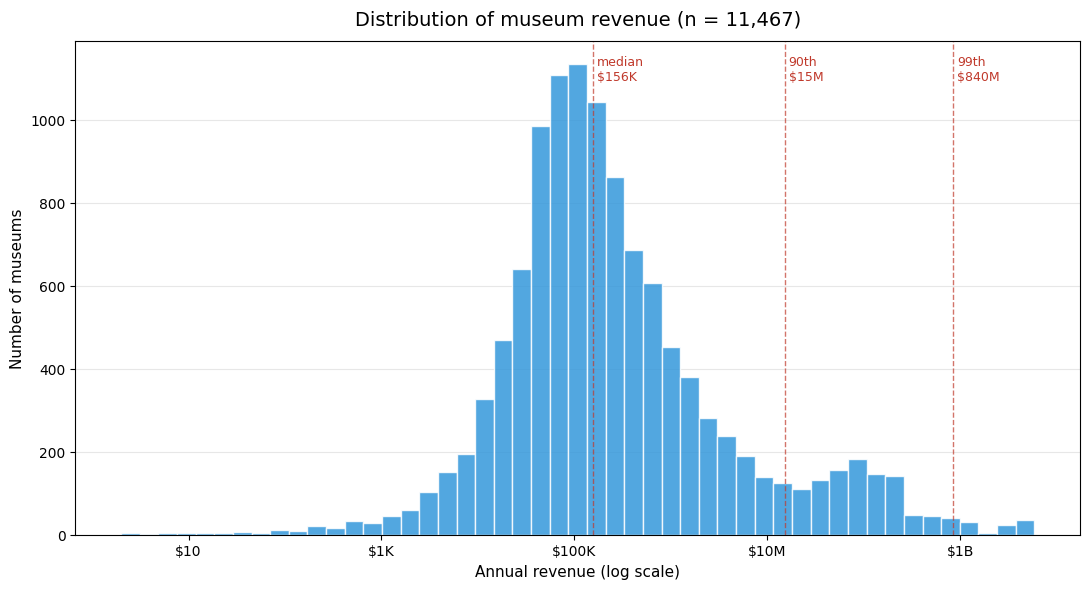

In [2]:
rev = df["Revenue"].dropna()
rev_pos = rev[rev > 0]  # log scale needs positive values; drops 40 negative rows

fig, ax = plt.subplots(figsize=(11, 6))
bins = np.logspace(np.log10(rev_pos.min()), np.log10(rev_pos.max()), 50)
ax.hist(rev_pos, bins=bins, color="#3498db", edgecolor="white", alpha=0.85)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(money_fmt)
ax.set_xlabel("Annual revenue (log scale)", fontsize=11)
ax.set_ylabel("Number of museums", fontsize=11)
ax.set_title("Distribution of museum revenue (n = {:,})".format(len(rev_pos)),
             fontsize=14, pad=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# Annotate percentile lines
for p, label in [(50, "median"), (90, "90th"), (99, "99th")]:
    v = np.percentile(rev_pos, p)
    ax.axvline(v, color="#c0392b", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(v * 1.1, ax.get_ylim()[1] * 0.92,
            f"{label}\n{money(v, None)}", fontsize=9, color="#c0392b")

plt.tight_layout()
plt.savefig("revenue_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

**What the chart shows:** the distribution is approximately log-normal but with a heavy right tail. Most museums sit in the $10K–$1M range (median = $156K). About 10% report revenue above $15M, and the top 1% — overwhelmingly parent universities filing 990s for their museum operations — exceed $840M. The sharp cluster around $1B–$10B isn't a feature of museum finance per se; it's the trailing edge created by Form 990 filings from large universities.

## Chart 2: Revenue distribution by museum type (box plot, log scale)

Box plots show the median, interquartile range, and outliers per category — much more robust than bar charts of means when distributions are heavily skewed.

/tmp/ipykernel_576/582648973.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=ordered_types,


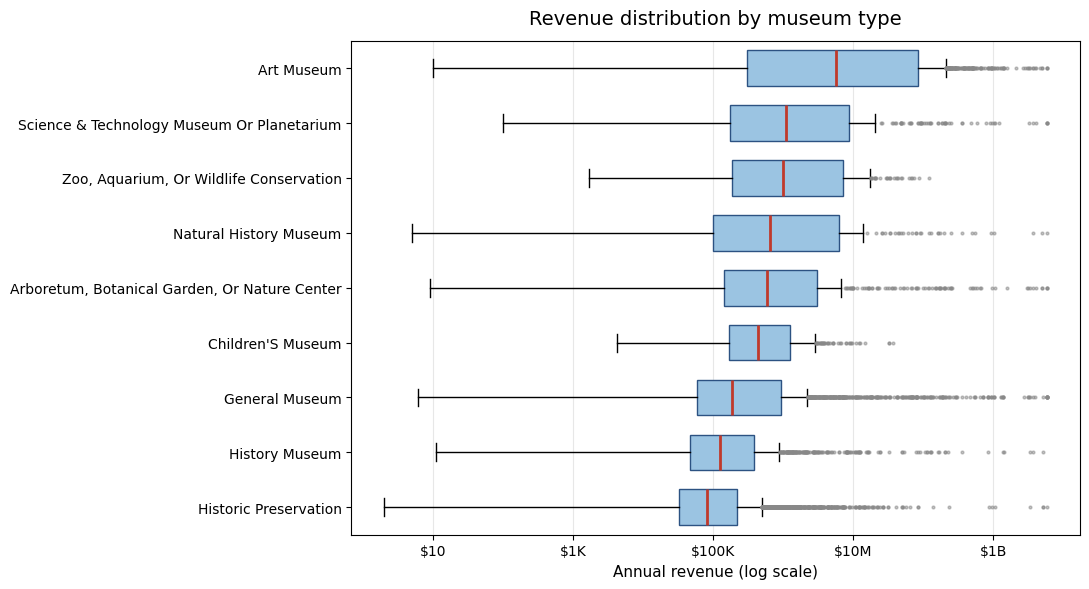

In [3]:
# Order types by median revenue, ascending (so highest medians appear at top)
type_medians = df.groupby("museum_type")["Revenue"].median().sort_values()
ordered_types = type_medians.index.tolist()

data = [df.loc[(df["museum_type"] == t) & (df["Revenue"] > 0), "Revenue"].values
        for t in ordered_types]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(data, vert=False, labels=ordered_types,
                patch_artist=True, widths=0.65,
                flierprops=dict(marker=".", markerfacecolor="#888",
                                 markeredgecolor="#888", markersize=4, alpha=0.5))
for box in bp["boxes"]:
    box.set_facecolor("#9bc4e2")
    box.set_edgecolor("#2c5282")
for med in bp["medians"]:
    med.set_color("#c0392b")
    med.set_linewidth(2)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(money_fmt)
ax.set_xlabel("Annual revenue (log scale)", fontsize=11)
ax.set_title("Revenue distribution by museum type", fontsize=14, pad=12)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("revenue_boxplot_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

**What the chart shows:** Art Museums sit highest (median ~$5.7M), with Science & Tech, Zoos/Aquariums, and Natural History grouped a tier below. Historic Preservation has the lowest median (~$81K) but the largest count, so its box of small filers extends with a long tail of large outlier filings (those are mostly university-affiliated historic sites). The many small dots to the right of each box are the parent-organization filings that dominate the means but don't shift the medians.

## Chart 3: Revenue vs. income (log–log scatter)

Form 990 reports both Total Revenue (operational inflows) and Total Income (revenue + investment returns). For most museums the two are nearly equal. For a handful of large endowed institutions, Income dramatically exceeds Revenue — a signal of investment-portfolio scale.

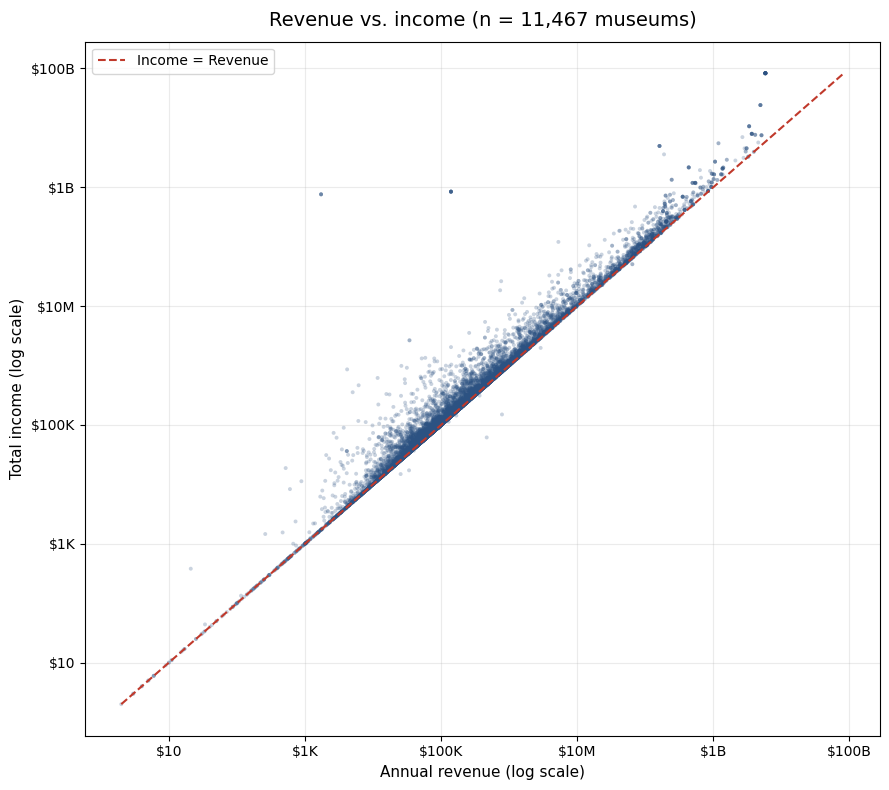

In [4]:
both = df[(df["Revenue"] > 0) & (df["Income"] > 0)]

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(both["Revenue"], both["Income"],
           s=8, alpha=0.25, color="#2c5282", edgecolor="none")

# Diagonal: where income equals revenue
lo, hi = both[["Revenue", "Income"]].min().min(), both[["Revenue", "Income"]].max().max()
ax.plot([lo, hi], [lo, hi], "--", color="#c0392b", linewidth=1.5,
        label="Income = Revenue")

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(money_fmt)
ax.yaxis.set_major_formatter(money_fmt)
ax.set_xlabel("Annual revenue (log scale)", fontsize=11)
ax.set_ylabel("Total income (log scale)", fontsize=11)
ax.set_title("Revenue vs. income (n = {:,} museums)".format(len(both)),
             fontsize=14, pad=12)
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="upper left", fontsize=10)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("revenue_vs_income.png", dpi=150, bbox_inches="tight")
plt.show()

**What the chart shows:** the bulk of museums cluster tightly along the diagonal — Income ≈ Revenue. Above the diagonal sit institutions whose investment income exceeds operating revenue — typically large universities reporting endowment returns. The points furthest above the line at the top right are the same parent-university filings (Harvard, Stanford, etc.) that have appeared throughout this analysis. There are very few points *below* the diagonal because Income is defined as Revenue + investment + other income, so it can rarely be smaller.

## What these three charts answer together

**The shape of museum revenue (Chart 1):** approximately log-normal with a heavy right tail. Half of all museums report less than $156K annually; the top 10% are above $15M. There's no single "typical" museum revenue — it depends on which order of magnitude you're interested in.

**Type drives a lot of the distribution (Chart 2):** Art museums and Zoos/Aquariums are consistently funded an order of magnitude above Historic Preservation and General Museums. The distinction is operational — institutions with permanent buildings, paid staff, and ticketed admissions report more revenue than volunteer-run historical societies.

**Revenue and income are nearly identical for most museums (Chart 3):** the income–revenue gap shows up only for very large endowed institutions. For data analysis purposes, Revenue is the more meaningful column for typical museums; Income is mostly relevant for the top couple of percent.

All three charts are also saved as PNGs (`revenue_histogram.png`, `revenue_boxplot_by_type.png`, `revenue_vs_income.png`) for reuse outside the notebook.